In [23]:
# Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [22]:
# Load data
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')



In [32]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [26]:
test.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal


In [27]:
print(train.shape)
print(test.shape)

(1460, 81)
(1459, 80)


In [28]:
target = train['SalePrice']
train = train.drop(['Id', 'SalePrice'], axis=1)
test_ids = test['Id']
test = test.drop('Id', axis=1)

# Combine for consistent preprocessing
df = pd.concat([train, test], axis=0, ignore_index=True)
df.shape

(2919, 79)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   int64  
 1   MSZoning       2915 non-null   object 
 2   LotFrontage    2433 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          198 non-null    object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2917 non-null   object 
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuil

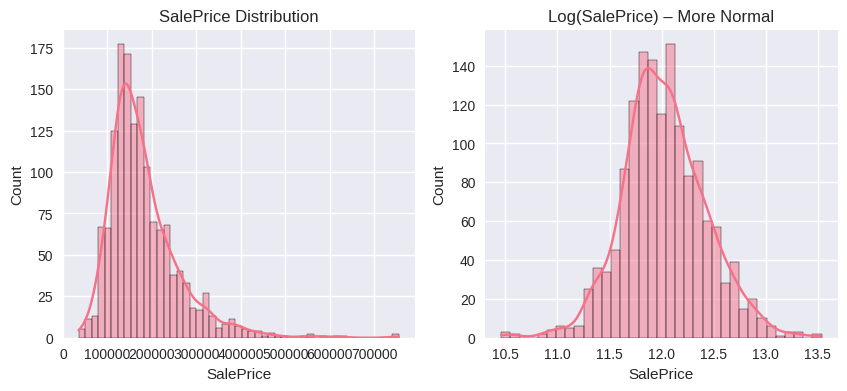

In [29]:
# Exploratory Data Analysis (Students love visuals!)
print(df.info())
print(df.describe())

# Target distribution
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(target, kde=True)
plt.title('SalePrice Distribution')

plt.subplot(1,2,2)
sns.histplot(np.log1p(target), kde=True)
plt.title('Log(SalePrice) – More Normal')
plt.show()

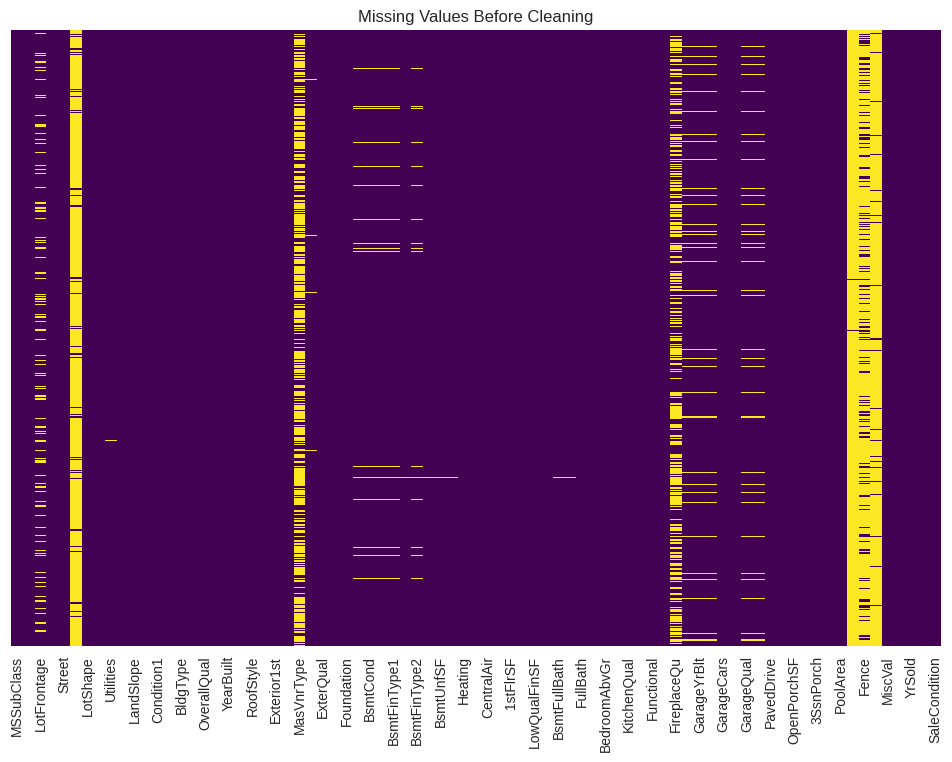

PoolQC          99.657417
MiscFeature     96.402878
Alley           93.216855
Fence           80.438506
MasVnrType      60.500171
FireplaceQu     48.646797
LotFrontage     16.649538
GarageQual       5.447071
GarageYrBlt      5.447071
GarageCond       5.447071
GarageFinish     5.447071
GarageType       5.378554
BsmtExposure     2.809181
BsmtCond         2.809181
BsmtQual         2.774923
BsmtFinType2     2.740665
BsmtFinType1     2.706406
MasVnrArea       0.787941
MSZoning         0.137033
BsmtFullBath     0.068517
Functional       0.068517
BsmtHalfBath     0.068517
Utilities        0.068517
BsmtFinSF1       0.034258
Exterior2nd      0.034258
Exterior1st      0.034258
Electrical       0.034258
TotalBsmtSF      0.034258
BsmtUnfSF        0.034258
BsmtFinSF2       0.034258
KitchenQual      0.034258
GarageArea       0.034258
GarageCars       0.034258
SaleType         0.034258
dtype: float64


In [30]:
# Missing Values Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Before Cleaning')
plt.show()

# Percentage missing
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing / len(df) * 100)

In [31]:
#  Smart Missing Value Handling (Teach logic!)
# Some NA actually mean "None" or "0" → check data_description.txt
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    df[col] = df[col].fillna(0)

# Simple imputation for rest
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))
df = df.fillna(df.mode().iloc[0])  # mode for categorical leftovers

In [ ]:
# Feature Engineering (Fun part!)
df['Age'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
df['TotalBath'] = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)

In [ ]:
# Encoding Categorical Variables
from sklearn.preprocessing import LabelEncoder

# Label encoding for ordinal features (students learn difference)
ordinal_map = {
    'ExterQual': {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1},
    'ExterCond': {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1},
    'BsmtQual':  {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0},
    'HeatingQC': {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1},
    'KitchenQual': {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1},
    'FireplaceQu': {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0},
    'GarageQual': {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0},
    'PoolQC': {'Ex':4, 'Gd':3, 'TA':2, 'Fa':1, 'None':0}
}

for col, mapping in ordinal_map.items():
    df[col] = df[col].map(mapping)

# One-hot encoding for nominal
df = pd.get_dummies(df, drop_first=True)
print(df.shape)  # ~300 columns now!

(2919, 244)


In [ ]:
#  Split back and modeling
X_train = df[:len(train)]
X_test  = df[len(train):]
y_train = np.log1p(target)   # Important: log transform target!

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Try multiple models
models = {
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5, random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    print(f"{name} CV RMSE: {rmse:.5f}")

RandomForest CV RMSE: 0.14345
GradientBoosting CV RMSE: 0.12646
XGBoost CV RMSE: 0.12984


In [ ]:
# Final Model + Submission
final_model = XGBRegressor(n_estimators=1000, learning_rate=0.02, max_depth=4,
                           subsample=0.8, colsample_bytree=0.8, random_state=42)
final_model.fit(X_train, y_train)

pred = np.expm1(final_model.predict(X_test))

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': pred
})
submission.to_csv('submission.csv', index=False)
print("Submission saved! Top 10% on Kaggle possible with this base")